# Lecture 8: Linear Optimization

[![Open In Colab](images/colab-badge.svg)](https://colab.research.google.com/github/UvA-SSO/simopt-lecture-notes/blob/main/notebooks/lecture8_linear-optimization.ipynb)

This notebook introduces linear optimization (LO), also called linear programming. It is
a widely used optimization framework in practice: efficient solvers exist that are
guaranteed to find the optimum even for problems with thousands of variables and
constraints. We introduce it through an example, model it, solve it in Python with
[pulp](https://coin-or.github.io/pulp/), look at what the solver is doing both graphically
and algebraically, and see what can go wrong.

**Learning outcomes**

On completion of this notebook, you will be able to:

- formulate a real-life decision problem as an LO model (decision variables, objective,
  constraints);
- implement an LO model in pulp, both directly and with the data kept separate from the
  model;
- understand the intuition behind the simplex method;
- interpret an LO solution both graphically and algebraically;
- recognize infeasibility and unboundedness in pulp's solve status.

## A Motivating Problem: Optimal Product Mix

A good way to introduce LO is through a concrete example. Consider a workshop that makes two products, **bookcases** and **desks**, from two limited resources,
**oak panels** and **assembly hours**. The following information is known per unit of product:

| product | profit (€) | oak panels needed | assembly hours needed |
|---------|---|---|---|
| bookcase | 3 | 1 | 2 |
| desk    | 5 | 3 | 1 |

For example, creating 2 bookcaes creates a profit of 6 and requires 2 oak panels and 4 assembly hours. There are 12 oak panels and 10 assembly hours available this week. The optimization problem is to find the product mix
that maximizes profit this week. For simplicity, we assume continuous amounts of bookcases and desks can
be made; [Integer Optimization](lecture8_integer-optimization.ipynb) revisits this example
with the added requirement that only whole numbers are allowed.

(modeling-approach)=
## The Modeling Approach

We follow the same four steps for every problem in this course:

1. **study the problem** in detail (done above);
2. **define the decision variables**: let $x$ and $y$ be the number of bookcases and
   desks produced, respectively;
3. **define the objective**: maximize profit, $3x + 5y$;
4. **define the constraints**: the oak-panel usage, $x + 3y$, cannot exceed 12; the
   assembly-hour usage, $2x + y$, cannot exceed 10; and $x, y \ge 0$.

In mathematical form:

$$
\begin{aligned}
\text{maximize} \quad & 3x + 5y & \text{(objective)} \\
\text{subject to} \quad & x + 3y \le 12 & \text{(oak panels)} \\
& 2x + y \le 10 & \text{(assembly hours)} \\
& x, y \ge 0.
\end{aligned}
$$

The objective and all constraints are linear functions of the decision variables
$(x, y)$, hence the name *linear* optimization.

## Solving the Model Directly in pulp

For a small, one-off model like this, the fastest way from model to answer is to write it
in pulp exactly as it appears above, with the numbers typed directly into the variable
bounds and constraints. We walk through it step by step; each step maps onto one of the
[four modeling steps](#modeling-approach) above.

### Import pulp

[pulp](https://coin-or.github.io/pulp/) is the Python package we use to build and solve
LO (and, later, ILO) models. Let's import it.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pulp

### Introduce the LP Problem

Python class `LpProblem` is pulp's container for a model: give it a name and a `sense`
(`LpMaximize` or `LpMinimize`) upon initialization.

In [2]:
product_mix = pulp.LpProblem(name="product_mix", sense=pulp.LpMaximize)

### Specify the Decision Variables (step 2)

Each decision variable becomes an `LpVariable` object; `lowBound=0` encodes $x, y \ge 0$. Optionally, we can set `cat` by giving a string that specifies the variable type, for example `"Continuous"`, `"Integer"`, or `"Binary"` (resulting in `LpContinuous`, `LpInteger`, or `LpBinary`, respectively). By default, `LpVariable` is continuous; we will see integer variables in [Integer Optimization](lecture8_integer-optimization.ipynb). Optionally, an `upBound` can be specified.

In [3]:
x = pulp.LpVariable(name="x", lowBound=0)
y = pulp.LpVariable(name="y", lowBound=0)

### Specify the Objective Function (step 3)

Add the objective to the problem with `+=`; the optional string names it for pulp's
output.

In [4]:
product_mix += 3 * x + 5 * y, "profit"

### Specify the Constraints (step 4)

Constraints are added the same way, one `+=` call per constraint. The comparison operators `<=`, `>=`, and `==` signify that a constraint is added (and not an objective).

In [5]:
product_mix += x + 3 * y <= 12, "oak_panels"
product_mix += 2 * x + y <= 10, "assembly_hours"

### Printing the Model

For small models, it is often useful to print the model to check that it was built correctly. pulp's `print()` method produces a human-readable version of the model.

In [6]:
print(product_mix)

product_mix:
MAXIMIZE
3*x + 5*y + 0
SUBJECT TO
oak_panels: x + 3 y <= 12

assembly_hours: 2 x + y <= 10

VARIABLES
x Continuous
y Continuous



### Solve and Check the Results

We are ready to solve the LO problem. We first load a solver and then use it in `.solve()`; `LpStatus` reports whether it found an optimum, and `.value()` reads off the variables and the objective.

In [7]:
solver = pulp.PULP_CBC_CMD(msg=False)
product_mix.solve(solver)
print("status:", pulp.LpStatus[product_mix.status])
print(f"x = {x.value()}, y = {y.value()}")
print("optimal profit:", product_mix.objective.value())

status: Optimal
x = 3.6, y = 2.8
optimal profit: 24.8


## Separating Data from the Model

The direct version above hardcodes every number into the model itself, which is fine for
a (small) problem you solve once. It breaks down as soon as you want to re-solve for different
data (more products, different resource limits) or reuse the same model code elsewhere:
every number would have to be found and edited inside the model-building code, which is
slow and error-prone. The fix is to keep the instance *data* in plain Python structures,
separate from the *model*-building code, and build the model from that data:

In [8]:
# data
profit = {"bookcase": 3, "desk": 5}
# resource_use[res][p]: units of resource res per unit of product p
resource_use = {
    "oak panels": {"bookcase": 1, "desk": 3},
    "assembly hours": {"bookcase": 2, "desk": 1},
}
available = {"oak panels": 12, "assembly hours": 10}
products = list(profit)

# modeling
product_mix = pulp.LpProblem(name="product_mix", sense=pulp.LpMaximize)
dec_vars = {p: pulp.LpVariable(name=p, lowBound=0) for p in products}

product_mix += pulp.lpSum(profit[p] * dec_vars[p] for p in products), "profit"
for res, cap in available.items():
    usage = pulp.lpSum(resource_use[res][p] * dec_vars[p] for p in products)
    product_mix += usage <= cap, res.replace(" ", "_")

# solving the model and printing the results
product_mix.solve(pulp.PULP_CBC_CMD(msg=False))
mix_solution = {p: dec_vars[p].value() for p in products}
optimal_profit = product_mix.objective.value()
print("status:", pulp.LpStatus[product_mix.status])
print("optimal mix:", mix_solution)
print("optimal profit:", optimal_profit)

status: Optimal
optimal mix: {'bookcase': 3.6, 'desk': 2.8}
optimal profit: 24.8


The model-building code (the `for` loop and the `pulp.lpSum` calls) no longer mentions 3,
5, 12, or 10 anywhere: it works unchanged for any number of products and resources, as
long as `profit`, `resource_use`, and `available` describe them. This is the pattern we
use for every larger model from here on, and it is also the discipline behind the
algebraic modeling languages (AMLs) introduced in
[Modeling Tools and Solvers](lecture10_modeling-tools.ipynb).

(larger-lo-example)=
## A Larger Example in pulp

The same three ingredients, and the same data/model split, scale to any size. Suppose the
workshop adds a third product, chairs, that uses 2 oak panels and 1 assembly hour
per unit and earns a profit of 4 per unit, and that both resources become a bit more
plentiful: 15 oak panels and 18 assembly hours. Only the *data* changes; the
model-building code stays exactly the same as in the previous section:

In [9]:
# data
profit = {"bookcase": 3, "desk": 5, "chair": 4}
# resource_use[res][p]: units of resource res per unit of product p
resource_use = {
    "oak panels": {"bookcase": 1, "desk": 3, "chair": 2},
    "assembly hours": {"bookcase": 2, "desk": 1, "chair": 1},
}
available = {"oak panels": 15, "assembly hours": 18}
products = list(profit)

# modeling
product_mix = pulp.LpProblem(name="product_mix", sense=pulp.LpMaximize)
dec_vars = {p: pulp.LpVariable(name=p, lowBound=0) for p in products}

product_mix += pulp.lpSum(profit[p] * dec_vars[p] for p in products), "profit"
for res, cap in available.items():
    usage = pulp.lpSum(resource_use[res][p] * dec_vars[p] for p in products)
    product_mix += usage <= cap, res.replace(" ", "_")

# solving the model and printing the results
product_mix.solve(pulp.PULP_CBC_CMD(msg=False))
print("status:", pulp.LpStatus[product_mix.status])
print("optimal mix:", {p: dec_vars[p].value() for p in products})
print("optimal profit:", product_mix.objective.value())

status: Optimal
optimal mix: {'bookcase': 7.0, 'desk': 0.0, 'chair': 4.0}
optimal profit: 37.0


The model-building code is a line-for-line copy of the two-product version; only the
data changed.

## A Graphical View

With only two decision variables we can draw the product-mix problem. Each constraint is
a line; the feasible region is the set of points satisfying all of them at once. Because
both the constraints and the objective are linear, the objective-value contour lines are
straight and parallel. Sliding one in the direction of increasing profit, the last
feasible point it touches is an optimal solution. Indeed, this may be a line segment if the objective function is parallel to a constraint. However, there is always a corner point of the feasible region that is optimal.

:::{exercise}
:label: ex-6-1

Derive by hand the corner points of the feasible region of the product-mix problem above,
evaluate the objective at each, and check which one pulp found.
:::

The code below only generates the figure. You do not need to learn this plotting code, so you can skip to the plot and use it to check your hand drawing, which you do need to master.

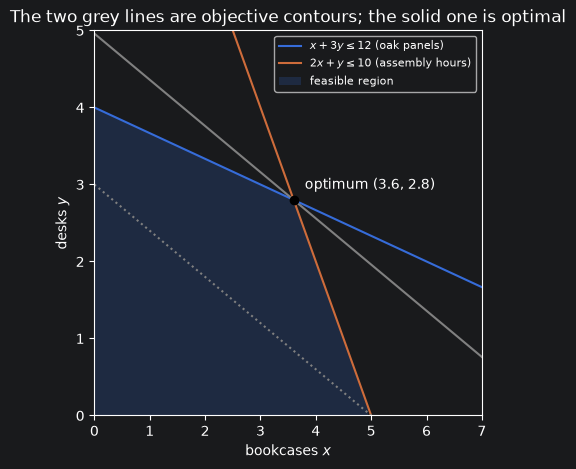

In [10]:
x_grid = np.linspace(0, 12, 200)
plt.figure(figsize=(5, 5))
plt.plot(
    x_grid,
    (12 - x_grid) / 3,
    color="C0",
    label=r"$x + 3y \leq 12$ (oak panels)",
)
plt.plot(
    x_grid,
    10 - 2 * x_grid,
    color="C1",
    label=r"$2x + y \leq 10$ (assembly hours)",
)
y_upper = np.minimum((12 - x_grid) / 3, 10 - 2 * x_grid)
plt.fill_between(
    x_grid,
    0,
    y_upper,
    where=(y_upper >= 0),
    alpha=0.2,
    label="feasible region",
)

x_opt, y_opt = mix_solution["bookcase"], mix_solution["desk"]
for level, style in [(15, ":"), (optimal_profit, "-")]:
    plt.plot(x_grid, (level - 3 * x_grid) / 5, style, color="grey")
plt.plot(x_opt, y_opt, "ko")
plt.annotate(
    f"optimum ({x_opt:.1f}, {y_opt:.1f})",
    (x_opt, y_opt),
    textcoords="offset points",
    xytext=(8, 8),
)

plt.xlim(0, 7)
plt.ylim(0, 5)
plt.xlabel("bookcases $x$")
plt.ylabel("desks $y$")
plt.legend(loc="upper right", fontsize=8)
plt.title(
    "The two grey lines are objective contours; the solid one is optimal"
)
plt.show()

The dotted grey line (profit 15) still has feasible points but we can do better; sliding
it out until it just leaves the feasible region gives the solid line, which touches the
region only at the corner where the two resource constraints meet: the optimum pulp
reported above.

:::{exercise}
:label: ex-lo-what-if

Suppose the assembly-hours availability increased from 10 to 14. Which line in the plot
moves, and in which direction would you expect the optimum to shift? Check your answer by
re-solving with pulp.
:::

## An Algebraic View

The same optimum can be understood without a picture. Turn each "$\le$" constraint into
an equality by adding a non-negative slack variable, the amount of the resource left
unused:

$$
\begin{aligned}
x + 3y \le 12 \\
2x + y \le 10 \\
x, y \ge 0
\end{aligned}
\quad\Leftrightarrow\quad
\begin{aligned}
x + 3y + s_1 &= 12 \\
2x + y + s_2 &= 10 \\
x, y, s_1, s_2 &\ge 0
\end{aligned}
$$

$s_1$ is the number of oak panels left unused, and $s_2$ is the number of assembly hours left unused.
There are now 2 equations and 4 variables. As a rule, a system of $k$ independent linear
equations in $k$ unknowns has generally one solution, so if we set any 2 of the 4 variables
to zero the other 2 are determined (where the two lines corresponding to the equations cross). Each such choice corresponds to a corner of the
feasible region (some combinations give a negative value and are infeasible; those are
corners of the lines' intersections that lie outside the feasible region). The corners here are:

- $(x, y, s_1, s_2) = (0, 0, 12, 10)$: the origin;
- $(5, 0, 7, 0)$: assembly hours fully used;
- $(0, 4, 0, 6)$: oak panels fully used;
- $(3.6, 2.8, 0, 0)$: both resource constraints tight, the optimum.

The simplex algorithm (G.B. Dantzig, 1947), which pulp's default solver uses for LO, hops
from corner to neighboring corner, each time to one with a better objective value, and
stops when no neighboring corner is better. Why is that enough to guarantee the *global*
optimum? Because the feasible region of an LO problem is a convex polyhedron: a shape with
flat faces and no hidden ``hills''. If every neighbor of your current corner is worse, there
is nowhere higher to go, since reaching a higher point would require the boundary to
curve, and linear constraints never curve. So for LO, a local optimum is automatically a
global optimum.

:::{note} History of Linear Optimization
Several researchers formulated linear optimization problems, but it was G.B. Dantzig
(1914–2005) who invented the simplex algorithm in 1947. Until recently the field was
commonly called *linear programming*. Its dynamic, random counterpart is *dynamic
programming*, developed by R.E. Bellman (1920–1984); the division between deterministic
and random problems is still very visible in operations research.
:::

## Three Possible Outcomes

Not every LO problem has an optimal solution. There are exactly three possibilities:

1. **an optimal solution exists** (the case above);
2. **unbounded**: solutions of arbitrarily large objective value exist. This cannot
   happen for the product-mix problem above, since every product uses some of both
   resources, but it can happen in general whenever some variable is left unconstrained,
   for example if the workshop also sold a service that used neither oak panels nor
   assembly hours;
3. **infeasible**: no point satisfies all constraints. This happens if, for example, a
   customer contract forces $y \ge 5$ while the oak-panel constraint allows at most
   $y = 4$.

pulp reports these as the `LpStatus` values `"Unbounded"` and `"Infeasible"` instead of
`"Optimal"`. [](#fig-lo-degenerate) shows both situations schematically.

:::{figure} images/lecture8_fig6.2.png
:label: fig-lo-degenerate

An unbounded (left) and an infeasible (right) LO problem.
:::

In the following we illustrate the unbounded and infeasible errors in pulp for the product-mix problem. For unboundedness, we add a third variable $s$ that uses no resources at all; for infeasibility, we add a customer contract that requires $y \ge 5$.:

In [11]:
unbounded_lp = pulp.LpProblem(name="unbounded_example", sense=pulp.LpMaximize)
x = pulp.LpVariable(name="x", lowBound=0)
y = pulp.LpVariable(name="y", lowBound=0)
s = pulp.LpVariable(
    name="s", lowBound=0
)  # a hypothetical service, no resources needed
unbounded_lp += 3 * x + 5 * y + 1 * s
unbounded_lp += x + 3 * y <= 12
unbounded_lp += 2 * x + y <= 10
# no constraint at all limits s

unbounded_lp.solve(pulp.PULP_CBC_CMD(msg=False))
print("status:", pulp.LpStatus[unbounded_lp.status])

status: Unbounded


In [12]:
infeasible_lp = pulp.LpProblem(
    name="infeasible_example", sense=pulp.LpMaximize
)
x = pulp.LpVariable(name="x", lowBound=0)
y = pulp.LpVariable(name="y", lowBound=0)
infeasible_lp += 3 * x + 5 * y
infeasible_lp += x + 3 * y <= 12
infeasible_lp += 2 * x + y <= 10
infeasible_lp += y >= 5  # the customer contract

infeasible_lp.solve(pulp.PULP_CBC_CMD(msg=False))
print("status:", pulp.LpStatus[infeasible_lp.status])

status: Infeasible


:::{exercise}
:label: ex-6-3

For what values of $a$ is adding the constraint $x >= a$ in the original problem feasible? Confirm it with `pulp`.
:::

(project-planning)=
## Another Application: Project Planning

(graphs-intro)=
A graph is a network of *nodes* (also called vertices) connected by *edges*; a directed
edge is called an *arc*. Many problems are naturally expressed on graphs. One is project
planning: a project has activities (nodes), each with a duration, and precedence
relations (arcs). An activity can only start once its predecessors are finished (you
cannot roof a house before the walls are up).

| activity | duration | must follow |
|---|---|---|
| A | 3 | none |
| B | 4 | none |
| C | 2 | A |
| D | 5 | A, B |
| E | 1 | C, D |
| F | 3 | D |

Let $x_i$ be the finish time of activity $i$. If $i$ precedes $j$ then
$x_i + d_j \le x_j$, where $d_j$ is the duration of $j$; also $x_i \ge d_i$. We want the
time when *all* activities are finished, $\max_i x_i$. That maximum is not linear (question to yourself: why not?), but we
can introduce a variable $z \ge x_i$ for all $i$ and minimize $z$: the optimization will
push $z$ down to exactly the largest finish time. This "min-max" trick reappears
throughout the course.

$$
\begin{aligned}
\text{minimize} \quad & z \\
\text{subject to} \quad & z \ge x_i \text{ for all activities } i \\
& x_i + d_j \le x_j \text{ if } i \text{ precedes } j \\
& x_i \ge d_i \text{ for all activities } i.
\end{aligned}
$$

In [13]:
duration = {"A": 3, "B": 4, "C": 2, "D": 5, "E": 1, "F": 3}
precedences = [
    ("A", "C"),
    ("A", "D"),
    ("B", "D"),
    ("C", "E"),
    ("D", "E"),
    ("D", "F"),
]

In [14]:
project = pulp.LpProblem(name="project_planning", sense=pulp.LpMinimize)
finish = {
    a: pulp.LpVariable(name=f"x_{a}", lowBound=duration[a]) for a in duration
}
makespan = pulp.LpVariable(name="z", lowBound=0)

for a in duration:
    project += makespan >= finish[a]
for before, after in precedences:
    project += finish[before] + duration[after] <= finish[after]

# minimize z; the tiny extra term only breaks ties, so activities that
# have slack still get their *earliest* finish time reported instead of an
# arbitrary one consistent with z.
project += makespan + 1e-4 * pulp.lpSum(finish[a] for a in duration)

project.solve(pulp.PULP_CBC_CMD(msg=False))
print(
    "earliest finish times:",
    {a: round(finish[a].value(), 2) for a in duration},
)
print("project finish time (makespan):", makespan.value())

earliest finish times: {'A': 3.0, 'B': 4.0, 'C': 5.0, 'D': 9.0, 'E': 10.0, 'F': 12.0}
project finish time (makespan): 12.0


The finish time can also be
found by a direct algorithm without LO, and that algorithm extends to *random* durations,
which matters because durations are often hard to predict, one reason IT projects
overrun.

:::{exercise}
:label: ex-6-7

Find the project finish time by hand: repeatedly take the activity whose predecessors are
all finished and give it the earliest possible finish time. Check you get the same
makespan as pulp.
:::

:::{exercise}
:label: ex-rewrite-proj-planning

Rewrite the project planning model above in case $x_i$ is the *start* time of activity $i$ instead of the finish time. Check that pulp gives the same makespan.
:::

## References

- Koole, G. (2019). *An Introduction to Business Analytics*. §6.1 "Problem Formulation",
  §6.3 "Example LO Problems" (project planning).